# Inference the results of the thrmodynamic experiment

In [2]:
import sys
import gc
sys.path.append('../')

In [3]:
from model.data_loader import fetch_dataloader,fetch_inference_loader
from model.data_loader import params as data_params
from model.model_cfg import CFG
# from model.net import ProteinEnergyNet
from model.hydro_net import PEM
from model.net import params as model_params
from train_utils import *
import torch
import torch.nn.functional as F
from torch import optim
from torch.optim import lr_scheduler
from tqdm import tqdm
import gc
import time
import sys
import pandas as pd
import wandb
import constants as C

/home/shaharax/.conda/envs/esm2_env/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
os.chdir("../")
os.getcwd()

'/casp15/Shahar/DeepPEF'

# set validation function

In [5]:
def get_exmample(data_loder_item, device):
    # get the inputs; data is a list of [inputs, labels]   
    id, crd_backbone, mask, seq_one_hot, seq,ang_backbone, ang, proT5_emb, proT5_mut,seq_mut = data_loder_item

    Xjf = crd_backbone.to(device) # wilde type structure folded
    Xkf = torch.clone(Xjf).to(device) # mutant structure folded
    Xju = torch.clone(Xjf).to(device) # wilde type structure unfolded
    Xku = torch.clone(Xjf).to(device) # mutant structure unfolded

    mask = mask.to(device)
    mask_decoy = torch.clone(mask).to(device)

    seq_one_hot = seq_one_hot.to(device) # [batch_size,seq_len,20]
    seq_one_hot_mut = get_one_hot(seq_mut[0]).to(device) # [batch_size,seq_len,20]

    emb = seq_one_hot.to(device)
    emb_decoy = seq_one_hot_mut.to(device)
    # move proT5_emb to device
    proT5_mut, proT5_emb = proT5_mut.to(device), proT5_emb.to(device)
    # squeeze the data
    Xjf, Xkf, Xju, Xku = Xjf.squeeze(), Xkf.squeeze(), Xju.squeeze(), Xku.squeeze()
    emb_decoy, emb = emb_decoy.squeeze(), emb.squeeze()
    mask_decoy, mask= mask_decoy.squeeze(), mask.squeeze()
    proT5_mut, proT5_emb = proT5_mut.squeeze(), proT5_emb.squeeze()
    # get folded graph  
    Xjf,Xkf = get_graph(Xjf, emb, proT5_emb, mask), get_graph(Xkf, emb, proT5_mut, mask)
    # get unfolded graph
    Xju,Xku = get_unfolded_graph(Xju, emb, proT5_emb, mask), get_unfolded_graph(Xku, emb, proT5_mut, mask)

    return Xjf,Xkf,Xju,Xku

In [6]:
model = PEM(layers=CFG.num_layers,gaussian_coef=CFG.gaussian_coef).to(CFG.device)
model.name = "PEM-thermodynamic cycle"
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
# Get total number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 393517


In [7]:

model_path = "./res/trianed_models_crd_decoy-30/3_final_model.pt"
model,optimizer,epoch,loss,valid_loss = load_checkpoint(model_path,model,optimizer,device=CFG.device)

Loaded model from ./res/trianed_models_crd_decoy-30/3_final_model.pt


1A0N example

In [8]:
def add_cb(crd_coords):
        """
        Add the Cbeta atom to the coordinates
        Args:
            crd_coords (tensor): tensor of shape [n_residues,3,3]

        Returns:
            crd_coords: tensor shape [n_residues,4,3]
        """
        # Get the coordinates of the backbone atoms
        N, CA, C = crd_coords[:, 0], crd_coords[:, 1], crd_coords[:, 2]
        # CB = CA + c1*(N-CA) + c2*(C-CA) + c3* (N-CA)x(C-CA)
        CAmN = N - CA
        # CAmN = CAmN / torch.sqrt(CAmN ** 2).sum(dim=2, keepdim=True)
        CAmC = C - CA
        # CAmC = CAmC / torch.sqrt(CAmC ** 2).sum(dim=2, keepdim=True)
        ANxAC = torch.cross(CAmN, CAmC, dim=1)

        A = torch.cat((CAmN.reshape(-1, 1), CAmC.reshape(-1, 1), ANxAC.reshape(-1, 1)), dim=1)
        c = torch.tensor([0.5507, 0.5354, -0.5691]) / 100  # torch.tensor([1.1930, 1.2106, -2.7906]) #
        b = (A @ c).reshape(-1,3)
        CB = CA - b
      
        # Add Cbeta coordinates to existing coordinates array
        crd_coords = torch.cat((crd_coords, CB.unsqueeze(1)), dim=1)
        return crd_coords
    

In [18]:
# item_path = './data/casp12_data_100/train/1A0N_2_B'
item_path = './data/casp12_data_100/train/1WR4_1_A'
# item_path = './data/casp12_data_100/train/2B89_1_A'
# load data
id = torch.load(item_path + '/id.pt')
crd_backbone = torch.tensor(torch.load(item_path + '/crd_backbone.pt'),dtype=torch.get_default_dtype()) #backbone coordinates N,Calpha,C
mask = torch.load(item_path + '/mask.pt')
# change to 1,0 mask
mask = torch.tensor(np.where(np.array(list(mask))=='+',1,0))
seq_one_hot = torch.load(item_path + '/seq_one_hot.pt')
seq = torch.load(item_path + '/seq.pt')
proT5_emb = torch.load(item_path + '/proT5_emb.pt')
# proT5_emb = torch.zeros((len(seq),1024)) # for testing
ang = torch.tensor(torch.load(item_path + '/ang.pt'))
ang_backbone = torch.clone(ang)[:,:3] #angles for the backbone phi, psi, omega
# Add Cbeta atom to the coordinates
crd_backbone = add_cb(crd_backbone)
crd_backbone = crd_backbone * C.NANO_TO_ANGSTROM # Convert to angstrom

# ProT5 embedding for protein mutation
proT5_mut = torch.load(item_path + '/proT5_emb_mut.pt')
seq_mut =  torch.load(item_path + '/seq_mut.pt')
# proT5_mut = torch.zeros((len(seq),1024)) # for testing
# seq_mut = seq # for testing
id, crd_backbone, mask, seq_one_hot, seq,ang_backbone, ang, proT5_emb, proT5_mut,seq_mut = [id], crd_backbone.unsqueeze(0), mask.unsqueeze(0), seq_one_hot.unsqueeze(0), [seq],ang_backbone.unsqueeze(0), ang.unsqueeze(0), proT5_emb.unsqueeze(0), proT5_mut.unsqueeze(0),[seq_mut]

In [19]:
print(mask)

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [20]:
# evaluate model 
model.train()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [21]:
# wild type and mutant type
Xjf = crd_backbone.to(device) # wilde type structure folded
Xkf = torch.clone(Xjf).to(device) # mutant structure folded
Xju = torch.clone(Xjf).to(device) # wilde type structure unfolded
Xku = torch.clone(Xjf).to(device) # mutant structure unfolded

# native structure and decoy structure
Xd = torch.clone(Xjf).to(device)
print(Xjf.shape,Xkf.shape,Xju.shape,Xku.shape,Xd.shape)
seq_one_hot = seq_one_hot.to(device) # [batch_size,20,seq_len]

# create decoy sequence
seq_decoy,mask_decoy, proT5_emb_decoy = mix_A_acid(seq_one_hot = seq_one_hot, emb=proT5_emb, mask = mask,val_type='train',device=device)

#emb = torch.cat((esm_embed,seq),dim=2)
emb = seq_one_hot.to(device)
emb_decoy = seq_decoy.to(device)
emb_mut = get_one_hot(seq_mut[0]).to(device)

# move proT5_emb to device
proT5_mut, proT5_emb_decoy, proT5_emb = proT5_mut.to(device), proT5_emb_decoy.to(device), proT5_emb.to(device)

# zero the parameter gradients
optimizer.zero_grad()
# squeeze the data
Xd, Xjf, Xkf, Xju, Xku = Xd.squeeze(), Xjf.squeeze(), Xkf.squeeze(), Xju.squeeze(), Xku.squeeze()
emb_decoy, emb, emb_mut = emb_decoy.squeeze(), emb.squeeze(), emb_mut.squeeze()
mask_decoy, mask= mask_decoy.squeeze(), mask.squeeze()
proT5_emb_decoy, proT5_emb, proT5_mut = proT5_emb_decoy.squeeze(), proT5_emb.squeeze(), proT5_mut.squeeze()

# get folded graph  
Xjf,Xkf = get_graph(Xjf, emb, proT5_emb, mask), get_graph(Xkf, emb_mut, proT5_mut, mask)
# get unfolded graph
Xju,Xku = get_unfolded_graph(Xju, emb, proT5_emb, mask), get_unfolded_graph(Xku, emb_mut, proT5_mut, mask)
# get decoy graph
Xd = get_graph(Xd, emb_decoy, proT5_emb_decoy, mask_decoy)
# create a batch of Xjf,Xkf,Xju,Xku,x_decoy
Xjf,Xkf,Xju,Xku,Xd = Xjf.unsqueeze(0),Xkf.unsqueeze(0),Xju.unsqueeze(0),Xku.unsqueeze(0),Xd.unsqueeze(0)    
# Xjf.requires_grad = True
X = torch.cat((Xjf,Xkf,Xju,Xku,Xd),dim=0)
# calculate the energy for the folded unfolded and decoy structure
E = model(X)
Ejf, Ekf, Eju, Eku, Exd = E[0], E[1], E[2], E[3], E[4]
   

torch.Size([1, 36, 4, 3]) torch.Size([1, 36, 4, 3]) torch.Size([1, 36, 4, 3]) torch.Size([1, 36, 4, 3]) torch.Size([1, 36, 4, 3])


In [22]:
print(Ejf.item(), Ekf.item(), Eju.item(), Eku.item(), Exd.item())

0.16594547033309937 0.28489387035369873 115.26028442382812 120.38611602783203 4842.5205078125


In [29]:
loss = (Ejf - Ekf) - (Eju - Eku)
loss.backward() 
print(model.parameters())
# print gradient norm
for p in model.parameters():
    if p.grad is not None:
        print(p.grad.norm())

<generator object Module.parameters at 0x7f68108b5ad0>
tensor(8.7109, device='cuda:0')
tensor(0.2104, device='cuda:0')
tensor(7.6532, device='cuda:0')
tensor(0.3041, device='cuda:0')
tensor(0.8640, device='cuda:0')
tensor(0.2106, device='cuda:0')
tensor(11.7032, device='cuda:0')
tensor(1.7105e-05, device='cuda:0')
tensor(10.7897, device='cuda:0')
tensor(0.0064, device='cuda:0')
tensor(0.6036, device='cuda:0')
tensor(0.0064, device='cuda:0')
tensor(2.1203, device='cuda:0')
tensor(0.7094, device='cuda:0')
tensor(15.3023, device='cuda:0')
tensor(0.6996, device='cuda:0')
tensor(13.9994, device='cuda:0')
tensor(0.9346, device='cuda:0')
tensor(4.9039, device='cuda:0')
tensor(0.6149, device='cuda:0')
tensor(1.8058, device='cuda:0')
tensor(1.7393e-06, device='cuda:0')
tensor(23.9164, device='cuda:0')
tensor(0.0197, device='cuda:0')
tensor(0.5825, device='cuda:0')
tensor(0.0197, device='cuda:0')
tensor(9.9563, device='cuda:0')
tensor(11.2124, device='cuda:0')
tensor(24.3942, device='cuda:0')
te

In [49]:
# calculate the energy difference
dE_wildtype = Eju - Ejf
dE_mutant = Eku - Ekf
dE_decoy = Exd - Ejf
# print as a table
print("Energy difference ")
print(f"Wild type: {dE_wildtype.item()}")
print(f"Mutant: {dE_mutant.item()}")
print(f"Decoy: {dE_decoy.item()}")

Energy difference 
Wild type: 1798.0
Mutant: 1695.0
Decoy: -458490.125


In [50]:
E = model(X,f_type = 'A_inference')
# E = E.squeeze()
Ejf, Ekf, Eju, Eku, Exd = E[0], E[1], E[2], E[3], E[4]

In [51]:
sum_Ejf, sum_Ekf, sum_Eju, sum_Eku, sum_Exd = (Ejf**2).sum(), (Ekf**2).sum(), (Eju**2).sum(), (Eku**2).sum(), (Exd**2).sum()
print(sum_Ejf.item(), sum_Ekf.item(), sum_Eju.item(), sum_Eku.item(), sum_Exd.item())
# delta E
dE_wildtype = sum_Eju - sum_Ejf
dE_mutant = sum_Eku - sum_Ekf
dE_decoy = sum_Exd - sum_Ejf
# print as a table
print("Energy difference ")
print(f"Wild type: {dE_wildtype.item()}")
print(f"Mutant: {dE_mutant.item()}")
print(f"Decoy: {dE_decoy.item()}")

1196351.5 1185904.5 1198149.5 1187599.5 737861.25
Energy difference 
Wild type: 1798.0
Mutant: 1695.0
Decoy: -458490.25


(36, 5)


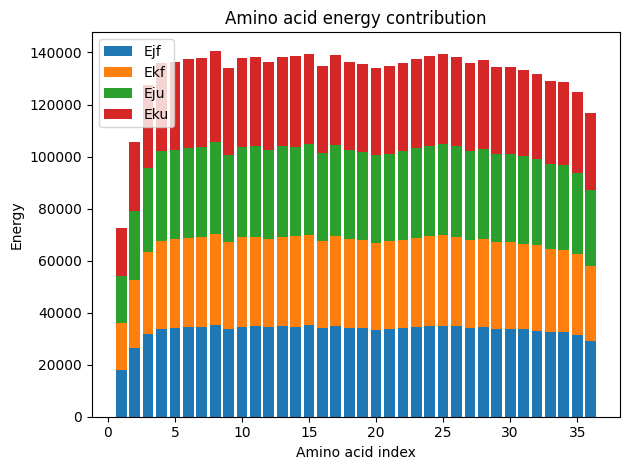

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [52]:
# Categories (x-axis labels)
nodes = Ejf.shape[0]
categories = np.arange(1, nodes+1)  # Assuming 69 data points


# Combine the data into a single array
data = np.hstack((Ejf.detach().cpu().numpy()**2, Ekf.detach().cpu().numpy()**2, Eju.detach().cpu().numpy()**2, Eku.detach().cpu().numpy()**2, Exd.detach().cpu().numpy()**2))
print(data.shape)
# Create the figure and axis objects
fig, ax = plt.subplots()

# Create the stacked bar chart
ax.bar(categories, data[:, 0], label='Ejf')
bottom = data[:, 0]
for i in range(1, data.shape[1]-1):
    ax.bar(categories, data[:, i], bottom=bottom, label=['Ejf', 'Ekf', 'Eju', 'Eku'][i])
    bottom += data[:, i]

# Set labels, title, and legend
plt.xlabel('Amino acid index')
plt.ylabel('Energy')
ax.set_title('Amino acid energy contribution')
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()
print(mask)

In [18]:
a = Eku**2-Ekf**2
a[a<0]

tensor([-4.6137e+01, -1.7553e+01, -1.6928e+01, -1.7422e+01, -2.8201e+01,
        -2.0902e+01, -3.4275e+01, -8.2020e+01, -9.1479e+01, -1.0200e+02,
        -8.4561e+01, -2.7709e+01, -3.4766e+00, -1.1930e+01, -4.9570e+00,
        -1.7059e+01, -4.0723e+00, -1.9297e+00, -5.4242e+01, -5.7268e+01,
        -8.7674e+01, -8.9766e+01, -9.6152e+01, -9.2307e+01, -5.9549e+01,
        -1.1055e+01, -2.9271e+01, -4.7990e+01, -5.6309e+01, -4.8672e+01,
        -2.4910e+01, -1.5094e+01, -3.2461e+00, -2.7336e+01, -8.3984e+00,
        -2.1484e-02], device='cuda:0', grad_fn=<IndexBackward0>)

In [28]:
d_params = data_params(num_workers =CFG.num_workers, batch_size=CFG.batch_size,cuda=CFG.cuda,constraint=CFG.constraint, debug=CFG.debug,dataset='scn')
train_loader, valid_loader,test_loader = fetch_dataloader(data_dir=CFG.data_path, params=d_params)

In [31]:
# define validation function
def validation(model, dataloader, device,epoch,N,optimizer,val_type = 'robust'):
    """
    Validation function for the model.
    """
    valid_loss = 0
    valid_lossd = 0
    valid_lossg = 0
    valid_lossc = 0
    Exd_list = []
    Exn_list = []
    seq_len = []
    lossg_list = []
    lossd_list = []
    ids_list = []
    n_skips = 0
    model.eval() # cant use eval because of the loss function calculation
    with tqdm(dataloader, unit="batch") as tepoch:
        # set progress bar description
        tepoch.set_description(f"Validation: Epoch {epoch}")
        for index, data in (enumerate(tepoch)):
            # Clean the GPU cache
            if(device.type == "cuda" or device.type == "mps"):    
                torch.cuda.empty_cache()
            gc.collect()
            # zero the parameter gradients
            optimizer.zero_grad()
            id, crd_backbone, mask, seq_one_hot, seq,ang_backbone, ang,\
                proT5_emb, proT5_mut,seq_mut, crd_decoy, mask_crd_decoy, seq_crd_decoy = data
            
            # wild type and mutant type
            Xjf = crd_backbone.to(device) # wilde type structure folded
            Xkf = torch.clone(Xjf).to(device) # mutant structure folded
            Xju = torch.clone(Xjf).to(device) # wilde type structure unfolded
            Xku = torch.clone(Xjf).to(device) # mutant structure unfolded
            Xcd = crd_decoy.to(device) # decoy structure

            # change the decoy len to match the native len
            if Xcd.shape[1] > Xjf.shape[1]:
                Xcd = Xcd[:,:Xjf.shape[1],:,:]
                mask_crd_decoy = mask_crd_decoy[:,:Xjf.shape[1]]
            elif Xcd.shape[1] < Xjf.shape[1]:
                # add zeros to the end of the decoy
                Xcd = torch.cat((Xcd, torch.zeros(Xjf.shape[0],Xjf.shape[1] - Xcd.shape[1], *Xcd.shape[2:]).to(device)), dim=1)
                mask_crd_decoy = torch.cat((mask_crd_decoy, torch.zeros(mask_crd_decoy.shape[0],mask.shape[1] - mask_crd_decoy.shape[1])), dim=1)
              
            # native structure and decoy structure
            Xd = torch.clone(Xjf).to(device)
            seq_one_hot = seq_one_hot.to(device) # [batch_size,20,seq_len]
            
            # create decoy sequence
            seq_decoy,mask_decoy, proT5_emb_decoy = mix_A_acid(seq_one_hot = seq_one_hot, emb=proT5_emb, mask = mask,val_type='train',device=device)
            
            if seq_decoy.shape[1] >CFG.seq_len : # if the sequence is too long, skip it(GPU limitation)
                n_skips += 1
                continue
            #emb = torch.cat((esm_embed,seq),dim=2)
            emb = seq_one_hot.to(device)
            emb_decoy = seq_decoy.to(device)
            emb_mut = get_one_hot(seq_mut[0]).to(device)
            
            # move proT5_emb to device
            proT5_mut, proT5_emb_decoy, proT5_emb = proT5_mut.to(device), proT5_emb_decoy.to(device), proT5_emb.to(device)
           
            # zero the parameter gradients
            optimizer.zero_grad()
            # squeeze the data
            Xd, Xjf, Xkf, Xju, Xku, Xcd = Xd.squeeze(), Xjf.squeeze(), Xkf.squeeze(), Xju.squeeze(), Xku.squeeze(), Xcd.squeeze()
            emb_decoy, emb, emb_mut = emb_decoy.squeeze(), emb.squeeze(), emb_mut.squeeze()
            mask_decoy, mask, mask_crd_decoy= mask_decoy.squeeze(), mask.squeeze(), mask_crd_decoy.squeeze()
            proT5_emb_decoy, proT5_emb, proT5_mut = proT5_emb_decoy.squeeze(), proT5_emb.squeeze(), proT5_mut.squeeze()
            
            # get folded graph  
            Xjf,Xkf = get_graph(Xjf, emb, proT5_emb, mask), get_graph(Xkf, emb_mut, proT5_mut, mask)
            # get unfolded graph
            Xju,Xku = get_unfolded_graph(Xju, emb, proT5_emb, mask), get_unfolded_graph(Xku, emb_mut, proT5_mut, mask)
            # get decoy graph
            Xd, Xcd = get_graph(Xd, emb_decoy, proT5_emb_decoy, mask_decoy), get_graph(Xcd, emb, proT5_emb, mask_crd_decoy)
            # create a batch of Xjf,Xkf,Xju,Xku,x_decoy
            Xjf,Xkf,Xju,Xku,Xd,Xcd = Xjf.unsqueeze(0),Xkf.unsqueeze(0),Xju.unsqueeze(0),Xku.unsqueeze(0),Xd.unsqueeze(0), Xcd.unsqueeze(0)    
            X = torch.cat((Xjf,Xkf,Xju,Xku,Xd,Xcd),dim=0)
            
             # half precision validation
            with torch.amp.autocast(device_type="cuda", dtype=CFG.precision):
                # calculate the energy for the folded unfolded and decoy structure
                E = model(X)
                Ejf, Ekf, Eju, Eku, Exd, Ecd = E[0], E[1], E[2], E[3], E[4], E[5]
                # calculate the loss   
                loss ,lossd, lossg,lossc = criterion(Ejf, Ekf, Eju, Eku, Exd, Xjf, Ecd, with_grad = False)
                
            # Add gradient penalty
            if CFG.gradient_penalty:
                # zero the parameter gradients
                optimizer.zero_grad()
                torch.cuda.empty_cache()
                gc.collect( )
                # half precision training
                with torch.amp.autocast(device_type="cuda", dtype=CFG.precision):
                    # calculate the energy for the wild type
                    Xjf.requires_grad = True
                    Ejf = model(Xjf)[0]
                    lossg = gradient_penalty(Xjf, Ejf)
                    
                loss += lossg # add the gradient penalty to the loss
            
            valid_loss += loss.item() 
            valid_lossd += lossd.item()
            valid_lossg += lossg.item()
            valid_lossc += lossc.item()
            # delete all the variables
            del Xjf,Xkf,Xju,Xku,Xd,emb_decoy, emb, emb_mut, mask_decoy, mask, proT5_emb_decoy, proT5_emb, proT5_mut, X, E, Ejf, Ekf, Eju, Eku, Exd
            torch.cuda.empty_cache()
            gc.collect()
            # update the progress bar
            if index % 1000 == 999:
                print(f"Validation loss: {round(valid_loss/(index + 1),2)}, index: {index}, n_skips: {n_skips}")
                validation_plots(Exd_list,Exn_list,seq_len,val_type,epoch)

            
    return valid_loss/len(dataloader),valid_lossd/len(dataloader),valid_lossg/len(dataloader),valid_lossc/len(dataloader)

def gradient_penalty(X_native, E_native):
    """Implementing the lossg equation:
        The gradient of a wild type structure should be close to zero.
        Therefore we will add it to the loss as lossg"""
    partial_dx_native = torch.autograd.grad(outputs=E_native, inputs=X_native, grad_outputs=torch.ones_like(E_native), create_graph=True)[0]
    part_dx_native_norm = 0.5*torch.norm(partial_dx_native,p=2)**2
    lossg = torch.log(part_dx_native_norm+1)
    return lossg

def criterion(Ejf, Ekf, Eju, Eku, Exd, X_native, Ecd, with_grad = True ):
    """
    The loss function for the model corresponds to 3 main losses:
    1. lossg: the partial derivative of the energy with respect to the native structure
    2. lossd: the energy of the native structure divided by the decoy energy
    3. lossc: the energy softplus function for the native and mutant structure(unfolded and folded)
    Args:
        Ejf (tensor): The energy of the folded native structure
        Ekf (tensor): The energy of the folded mutant structure
        Eju (tensor): The energy of the unfolded native structure
        Eku (tensor): The energy of the unfolded mutant structure
        Exd (tensor): The energy of the decoy sequence
        Ecd (tensor): The energy of the decoy structure
    output:
        loss (tensor): The loss of the model
        lossd (tensor): The loss of the model due to the energy of the native structure divided by the decoy energy
        lossg (tensor): The loss of the model due to the partial derivative of the energy with respect to the native structure
        lossc (tensor): The loss of the model due to the energy softplus function for the native and mutant structure(unfolded and folded)
    """
    lossg = gradient_penalty(X_native, Ejf) if with_grad else torch.tensor(0.0).to(Ejf.device)
    lossd = (torch.log((Ejf+1) / (Exd+1) +1)) + (torch.log((Ejf+1) / (Ecd+1) +1))
    lossc = energy_softplus(Ejf, Ekf, Eju, Eku)
    
    return lossd+lossg+lossc , lossd, lossg, lossc

def energy_softplus(Ejf, Ekf, Eju, Eku, beta = 1):
    """Energy softplus,
    As we know the energy diffrence between an unfolded protein and folded protein is positive.
    Therefore we will add it to the loss as lossd"""
    softplus = torch.nn.Softplus(beta=beta)
    
    lossd1 = softplus(Ekf-Eku)
    lossd1 =  torch.where(lossd1 < 0.05, torch.tensor(0.0).to(lossd1.device), torch.min(torch.tensor(10.0).to(lossd1.device), lossd1))
    
    lossd2 = softplus(Ejf-Eju)
    lossd2 = torch.where(lossd2 < 0.05, torch.tensor(0.0).to(lossd2.device), torch.min(torch.tensor(10.0).to(lossd2.device), lossd2))
    return lossd1+lossd2

In [32]:
validation(model, valid_loader,CFG.device,epoch, CFG.N, optimizer )

Validation: Epoch 3: 100%|██████████| 160/160 [01:36<00:00,  1.65batch/s]


(nan, 1.721603774279356, nan, 9.878599621355534)

In [22]:
torch.cuda.empty_cache()
gc.collect()
memory_allcation = torch.cuda.memory_allocated(device=device)
memory_cached = torch.cuda.memory_cached(device=device)
print(f"memory allocated: {round(memory_allcation/1e9,3)}, memory cached: {round(memory_cached/1e9,3)}")

memory allocated: 0.264, memory cached: 0.304


/home/shaharax/.conda/envs/esm2_env/lib/python3.7/site-packages/torch/cuda/memory.py:397: FutureWarning: torch.cuda.memory_cached has been renamed to torch.cuda.memory_reserved
  FutureWarning)


In [23]:
!nvidia-smi

Sun Nov 12 10:56:30 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX 6000 Ada Gener...    On | 00000000:61:00.0 Off |                  Off |
| 30%   34C    P2               70W / 300W|   1627MiB / 49140MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--